# Stroke Risk Prediction — Modeling (V4)
**Dataset** : Ping Wang (2024), *Imbalanced Data-based Prediction and Risk Factor Analysis of Stroke*, Mendeley Data.  
**Source** : NHANES (National Health and Nutrition Examination Survey)  
**DOI** : [10.17632/xggs239bnw.1](https://doi.org/10.17632/xggs239bnw.1)

---

## Pipeline Modeling

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports + Chargement | 1 | `config.py` + librairies + `df_features.csv` + `load_features()` |
| Features Sélectionnées | 2 | Chargées depuis `df_features.csv` — feature selection faite en V2 |
| Split stratifié | 3 | 80/20 sur `SELECTED_FEATURES` — `stratify=y` |
| ImbPipeline + ADASYN | 4 | `ADASYN` → `ColumnTransformer(StandardScaler)` → `Model` sur `X_train` uniquement |
| RandomizedSearchCV | 5 | Optimisation `scoring='recall'` sur 4 modèles |
| Évaluation | 6 | Accuracy, Recall, F1, AUC-ROC — comparaison des 4 modèles |
| Visualisation | 7 | Barplot métriques + Confusion matrices + Courbes ROC |
| Analyse des seuils | 8 | Trade-off Recall/Accuracy — seuil optimal par modèle |
| Résultats finaux | 9 | Résultats avec seuil optimal par modèle |
| Analyse faux négatifs | 10 | Quels AVC sont manqués ? Sélection best model : AUC max parmi Recall≥0.60 ET Seuil≥0.10 |
| Permutation Importance | 11 | Variables les plus importantes |
| Conclusion | 12 | Performance + comparaison V1→V4 |
| Sauvegarde | 13 | `pipeline.pkl` + `features.pkl` |

---

**Amélioration V4 vs V3 :**  
- `SMOTE` remplacé par **`ADASYN`** — génère plus d'exemples dans les zones difficiles  
- Ajout de **`LightGBM`** — 4ème modèle  
- `ColumnTransformer` — scale uniquement `NUM_SELECTED` (catégorielles passées en passthrough)  
- Sélection best model corrigée : **AUC-ROC max** parmi Recall ≥ 0.60 ET Seuil ≥ 0.10  

**Prérequis** : `2_Preprocessing_v2.ipynb` exécuté  
**Sortie** : `pipeline.pkl` + `features.pkl`  
**Métrique prioritaire** : **Recall** — faux négatif = AVC non détecté


## 1. Imports, Chargement & Variables

In [1]:
%pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

# Vider le cache — évite que Python utilise config.py d'un autre notebook
sys.path = [p for p in sys.path if 'src' not in p]
if 'config' in sys.modules:
    del sys.modules['config']

# Ajouter le src de V4
sys.path.insert(0, os.path.abspath('./src'))

import importlib
import config
importlib.reload(config)
from config import TARGET, RANDOM_STATE, CLEAN_PATH, check_data_quality, load_features, FEATURES_PATH

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Chargement variables et dataset
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

df = pd.read_csv(FEATURES_PATH)
df = df.drop_duplicates().reset_index(drop=True)
is_clean = check_data_quality(df)
if not is_clean:
    raise ValueError('Dataset non propre — relancer 2_Preprocessing_v2.ipynb.')

print(f'Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes')


features.json charge :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 18 colonnes
Dataset chargé : 4603 lignes x 18 colonnes


## 2. Features Sélectionnées

`df_features.csv` contient déjà les features issues de la feature selection V2.  
On définit ici `SELECTED_FEATURES` directement depuis le dataset chargé — pas de feature selection répétée.

In [3]:
SELECTED_FEATURES = [col for col in df.columns if col != TARGET]
NUM_SELECTED      = [col for col in SELECTED_FEATURES if col in NUMERICAL_VARS]

print(f'Features sélectionnées : {len(SELECTED_FEATURES)}')
print(f'  Numériques           : {len(NUM_SELECTED)}')
print(f'  Catégorielles        : {len(SELECTED_FEATURES) - len(NUM_SELECTED)}')
print(f'  {SELECTED_FEATURES}')

Features sélectionnées : 17
  Numériques           : 7
  Catégorielles        : 10
  ['age', 'Coronary Heart Disease', 'General health condition', 'protein', 'high cholesterol', 'Total polyunsaturated fatty acids', 'depression', 'hypertension', 'diabetes', 'Low-density lipoprotein', 'smoke', 'Health Insurance', 'Dietary fiber', 'Total saturated fatty acids', 'Carbohydrate', 'Minutes sedentary activity', 'Race']


## 3. Split stratifié — 80/20

Identique à V3.  
**ADASYN sera appliqué uniquement sur `X_train`** à l'intérieur du pipeline.


In [4]:
X = df[SELECTED_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('=== Train / Test Split ===')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
vc_train = y_train.value_counts()
vc_test  = y_test.value_counts()
print(f'y_train — No stroke: {vc_train[0]} ({vc_train[0]/len(y_train)*100:.1f}%)  Stroke: {vc_train[1]} ({vc_train[1]/len(y_train)*100:.1f}%)')
print(f'y_test  — No stroke: {vc_test[0]}  ({vc_test[0]/len(y_test)*100:.1f}%)  Stroke: {vc_test[1]}  ({vc_test[1]/len(y_test)*100:.1f}%)')
print()
print('ADASYN appliqué uniquement sur X_train — à l\'intérieur du pipeline.')


=== Train / Test Split ===
X_train : (3682, 17)  |  X_test : (921, 17)
y_train — No stroke: 3392 (92.1%)  Stroke: 290 (7.9%)
y_test  — No stroke: 849  (92.2%)  Stroke: 72  (7.8%)

ADASYN appliqué uniquement sur X_train — à l'intérieur du pipeline.


## 4. ImbPipeline + ADASYN

**ADASYN vs SMOTE :**  
- SMOTE génère des exemples synthétiques **uniformément** entre les points minority  
- ADASYN génère **plus d'exemples dans les zones difficiles**

**Ordre obligatoire :**
1. `ADASYN` — rééquilibrage adaptatif sur `X_train` uniquement
2. `ColumnTransformer(StandardScaler)` — normalisation sur `NUM_SELECTED` uniquement
3. `Model` — LR / RF / XGBoost / LightGBM

Pas de `class_weight='balanced'` — doublon avec ADASYN.


In [5]:
def make_imb_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), NUM_SELECTED)],
        remainder='passthrough'
    )
    return ImbPipeline(steps=[
        ('adasyn', ADASYN(random_state=RANDOM_STATE)),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

pipelines = {
    'Logistic Regression': make_imb_pipeline(
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    ),
    'Random Forest': make_imb_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE)
    ),
    'XGBoost': make_imb_pipeline(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    ),
    'LightGBM': make_imb_pipeline(
        LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
    )
}

print(f'{len(pipelines)} pipelines — ADASYN + ColumnTransformer(StandardScaler) + modèle')
for name in pipelines:
    print(f'  - {name}')


4 pipelines — ADASYN + ColumnTransformer(StandardScaler) + modèle
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM


## 5. RandomizedSearchCV — Optimisation

`RandomizedSearchCV` explore aléatoirement `n_iter` combinaisons.  
`scoring='recall'` — on optimise directement la métrique médicale prioritaire.

In [6]:
# Espaces de recherche par modèle
param_grids = {
    'Logistic Regression': {
        'model__C'      : [0.01, 0.1, 1, 10, 100],
        'model__solver' : ['lbfgs', 'liblinear']
    },
    'Random Forest': {
        'model__n_estimators'     : [100, 200, 300],
        'model__max_depth'        : [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'model__n_estimators' : [100, 200, 300],
        'model__max_depth'    : [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample'    : [0.7, 0.8, 1.0]
    },
    'LightGBM': {
        'model__n_estimators' : [100, 200, 300],
        'model__max_depth'    : [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__num_leaves'   : [20, 31, 50]
    }
}

best_models = {}

for name, pipeline in pipelines.items():
    print(f'\nOptimisation : {name} ...')

    search = RandomizedSearchCV(
        estimator           = pipeline,
        param_distributions = param_grids[name],
        n_iter              = 50,
        scoring             = 'recall',
        cv                  = 5,
        random_state        = RANDOM_STATE,
        n_jobs              = -1
    )
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    print(f'  Meilleurs paramètres : {search.best_params_}')
    print(f'  Recall CV            : {search.best_score_:.4f}')



Optimisation : Logistic Regression ...
  Meilleurs paramètres : {'model__solver': 'liblinear', 'model__C': 0.01}
  Recall CV            : 0.4897

Optimisation : Random Forest ...
  Meilleurs paramètres : {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__max_depth': 5}
  Recall CV            : 0.4483

Optimisation : XGBoost ...
  Meilleurs paramètres : {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
  Recall CV            : 0.5138

Optimisation : LightGBM ...
  Meilleurs paramètres : {'model__num_leaves': 20, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
  Recall CV            : 0.5103


In [7]:
# Modèles retenus — RandomizedSearchCV
best_models_final = best_models
print('Modèles retenus : RandomizedSearchCV')
for name in best_models_final:
    print(f'  - {name}')


Modèles retenus : RandomizedSearchCV
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM


## 6. Évaluation sur X_test

In [8]:
results = []
colors  = ['#4C9BE8', '#6DBF8E', '#E8614C', '#F4A261']

for name, model in best_models_final.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Résultats V4 — GridSearchCV + ADASYN ===')
print(results_df.to_string())


=== Résultats V4 — GridSearchCV + ADASYN ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.5852     0.0765  0.3889  0.1279   0.5317
Random Forest          0.5342     0.0800  0.4722  0.1368   0.5358
XGBoost                0.4712     0.0858  0.5972  0.1501   0.5418
LightGBM               0.4506     0.0827  0.5972  0.1453   0.5350


## 7. Visualisation des Résultats

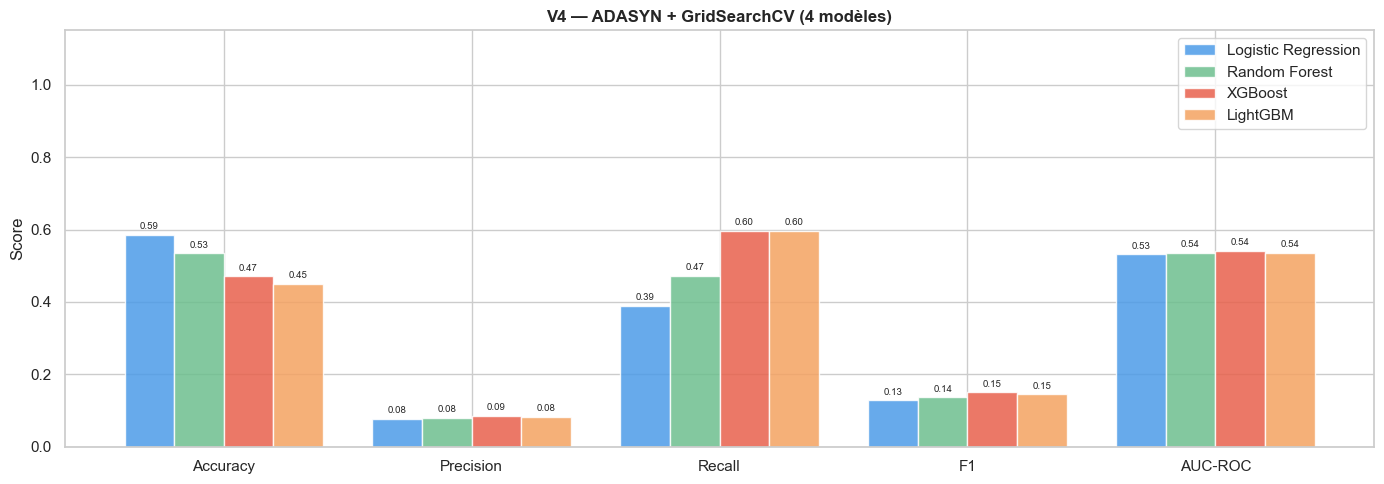

In [9]:
# Barplot comparatif
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(metrics_cols))
width = 0.20

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('V4 — ADASYN + GridSearchCV (4 modèles)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

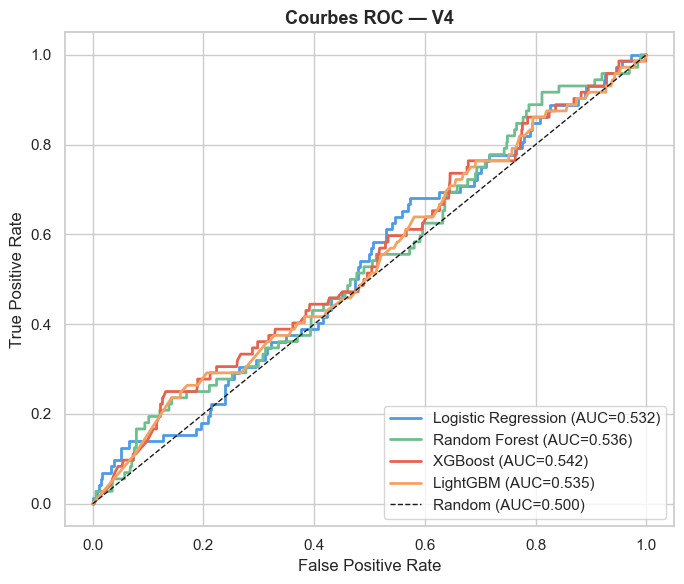

In [10]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, model) in enumerate(best_models_final.items()):
    y_prob      = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — V4', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Analyse des Seuils — Tous les Modèles

On cherche le seuil optimal par modèle :  
**Contrainte médicale** : Recall >= 0.70  
**Critère** : meilleur F1 parmi les seuils valides



=== Logistic Regression ===
 Seuil  Accuracy  Recall     F1
  0.10    0.0923  1.0000 0.1469
  0.15    0.1064  0.9861 0.1472
  0.20    0.1444  0.9444 0.1472
  0.25    0.2020  0.8889 0.1483
  0.30    0.2628  0.8194 0.1481
  0.35    0.3268  0.7500 0.1484
  0.40    0.4321  0.6806 0.1578
  0.45    0.5168  0.5417 0.1491
  0.50    0.5852  0.3889 0.1279
  0.55    0.6830  0.3056 0.1310
  0.60    0.7546  0.1806 0.1032
  0.65    0.8350  0.1389 0.1163
  0.70    0.8827  0.1250 0.1429
  0.75    0.9110  0.0556 0.0889
  0.80    0.9186  0.0139 0.0260
  0.85    0.9207  0.0000 0.0000
Meilleur seuil (F1 max) : 0.35

=== Random Forest ===
 Seuil  Accuracy  Recall     F1
  0.10    0.0912  0.9861 0.1450
  0.15    0.1151  0.9583 0.1448
  0.20    0.1585  0.9306 0.1474
  0.25    0.2410  0.9167 0.1588
  0.30    0.2921  0.8194 0.1532
  0.35    0.3312  0.7500 0.1492
  0.40    0.3692  0.6944 0.1468
  0.45    0.4311  0.5833 0.1382
  0.50    0.5342  0.4722 0.1368
  0.55    0.6743  0.3056 0.1279
  0.60    0.8078  0.2

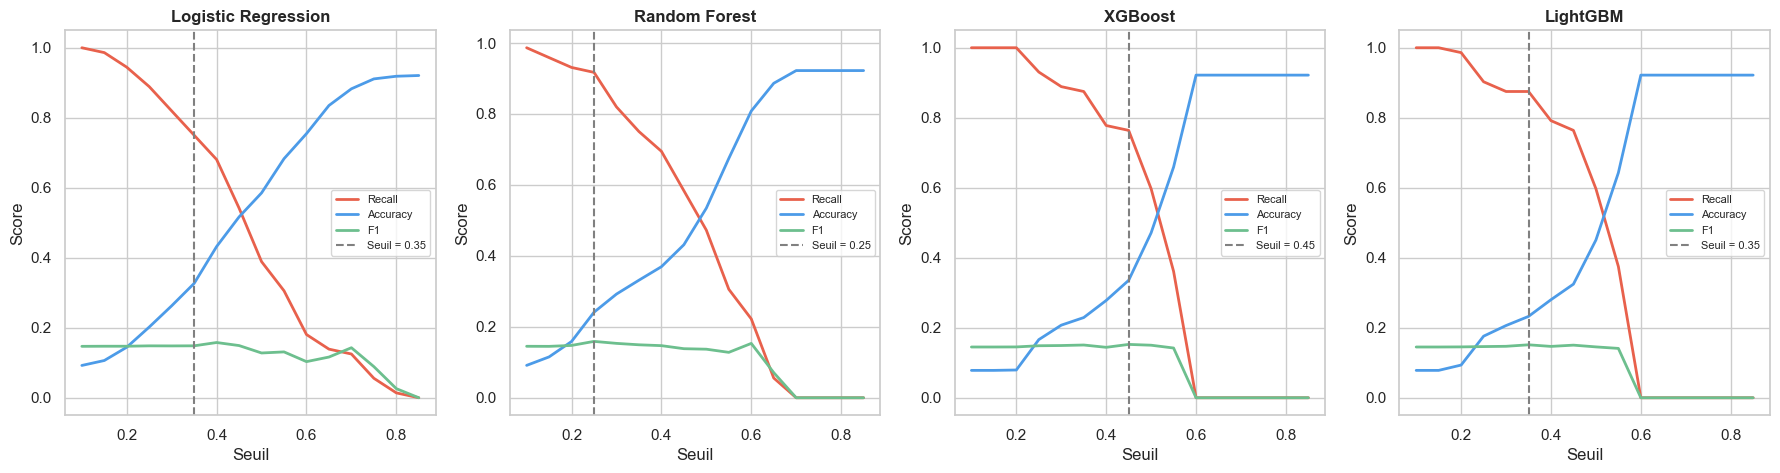

In [11]:
thresholds     = np.arange(0.1, 0.9, 0.05)
best_thresholds = {}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, (name, model) in enumerate(best_models_final.items()):
    y_prob         = model.predict_proba(X_test)[:, 1]
    results_thresh = []

    for thresh in thresholds:
        y_pred_thresh = (y_prob >= thresh).astype(int)
        results_thresh.append({
            'Seuil'   : round(thresh, 2),
            'Accuracy': round(accuracy_score(y_test, y_pred_thresh), 4),
            'Recall'  : round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
            'F1'      : round(f1_score(y_test, y_pred_thresh, zero_division=0), 4),
        })

    thresh_df   = pd.DataFrame(results_thresh)
    
    thresh_filtered = thresh_df[thresh_df['Recall'] >= 0.70]
    
    if len(thresh_filtered) > 0:
        best_thresh = thresh_filtered.loc[thresh_filtered['F1'].idxmax(), 'Seuil']
    else:
        best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Seuil']

    best_thresholds[name] = best_thresh

    print(f'\n=== {name} ===')
    print(thresh_df.to_string(index=False))
    print(f'Meilleur seuil (F1 max) : {best_thresh}')

    axes[i].plot(thresh_df['Seuil'], thresh_df['Recall'],   label='Recall',   color='#E8614C', linewidth=2)
    axes[i].plot(thresh_df['Seuil'], thresh_df['Accuracy'], label='Accuracy', color='#4C9BE8', linewidth=2)
    axes[i].plot(thresh_df['Seuil'], thresh_df['F1'],       label='F1',       color='#6DBF8E', linewidth=2)
    axes[i].axvline(x=best_thresh, color='gray', linestyle='--', label=f'Seuil = {best_thresh}')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Seuil')
    axes[i].set_ylabel('Score')
    axes[i].legend(fontsize=8)
    

In [12]:
## 9. Résultats Finaux — Seuil Optimal par Modèle

In [13]:
results_final = []

for name, model in best_models_final.items():
    y_prob        = model.predict_proba(X_test)[:, 1]
    best_thresh   = best_thresholds[name]
    y_pred_thresh = (y_prob >= best_thresh).astype(int)

    results_final.append({
        'Model'    : name,
        'Seuil'    : best_thresh,
        'Accuracy' : round(accuracy_score(y_test, y_pred_thresh), 4),
        'Precision': round(precision_score(y_test, y_pred_thresh, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred_thresh, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_final_df = pd.DataFrame(results_final).set_index('Model')
print('=== Résultats Finaux V4 — Seuil Optimal par Modèle ===')
print(results_final_df.to_string())

=== Résultats Finaux V4 — Seuil Optimal par Modèle ===
                     Seuil  Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                                   
Logistic Regression   0.35    0.3268     0.0823  0.7500  0.1484   0.5317
Random Forest         0.25    0.2410     0.0870  0.9167  0.1588   0.5358
XGBoost               0.45    0.3355     0.0846  0.7639  0.1524   0.5418
LightGBM              0.35    0.2324     0.0828  0.8750  0.1513   0.5350


## 10. Analyse des Erreurs — Faux Négatifs

Dans un contexte médical, les **faux négatifs** sont les erreurs les plus graves —  
un patient avec AVC prédit comme sain.


In [14]:
# Sélection best model : AUC-ROC max parmi Recall >= 0.60 ET Seuil >= 0.10
valid = results_final_df[
    (results_final_df['Recall'] >= 0.60) &
    (results_final_df['Seuil'] >= 0.10)
]

if len(valid) > 0:
    best_name = valid['AUC-ROC'].idxmax()
else:
    best_name = results_final_df['AUC-ROC'].idxmax()

best_thresh = best_thresholds[best_name]
best_model  = best_models_final[best_name]

print(f'Meilleur modèle : {best_name}')
print(f'  Seuil optimal : {best_thresh}')
print(f'  Recall        : {results_final_df.loc[best_name, "Recall"]:.4f}')
print(f'  Accuracy      : {results_final_df.loc[best_name, "Accuracy"]:.4f}')
print(f'  AUC-ROC       : {results_final_df.loc[best_name, "AUC-ROC"]:.4f}')

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_thresh).astype(int)

fn_mask = (y_test == 1) & (y_pred == 0)
fp_mask = (y_pred == 1) & (y_test == 0)

print(f'\nFaux Négatifs (AVC manqués)   : {fn_mask.sum()}')
print(f'Faux Positifs (fausse alarme)  : {fp_mask.sum()}')

fn_df = X_test[fn_mask].copy()
tp_df = X_test[(y_test == 1) & (y_pred == 1)].copy()

print('\n=== Profil moyen des Faux Négatifs vs Vrais Positifs ===')
compare = pd.DataFrame({
    'Faux Négatifs (manqués)'  : fn_df.mean().round(3),
    'Vrais Positifs (détectés)': tp_df.mean().round(3)
})
display(compare)


Meilleur modèle : XGBoost
  Seuil optimal : 0.45
  Recall        : 0.7639
  Accuracy      : 0.3355
  AUC-ROC       : 0.5418

Faux Négatifs (AVC manqués)   : 17
Faux Positifs (fausse alarme)  : 595

=== Profil moyen des Faux Négatifs vs Vrais Positifs ===


,Faux Négatifs (manqués),Vrais Positifs (détectés)
age,2.118,2.473
Coronary Heart Disease,0.235,0.164
General health condition,3.824,3.509
protein,91.214,66.262
high cholesterol,0.647,0.527
Total polyunsaturated fatty acids,23.208,15.649
depression,1.235,1.364
hypertension,0.765,0.873
diabetes,0.588,0.273
Low-density lipoprotein,2.313,2.958


## 11. Permutation Importance

La **Permutation Importance** mesure l'impact de chaque feature sur le recall.

=== Permutation Importance — XGBoost ===
                          Feature  Importance
                          protein    0.065278
                 Health Insurance    0.033333
Total polyunsaturated fatty acids    0.022222
                              age    0.020833
          Low-density lipoprotein    0.015278
                             Race    0.012500
                            smoke    0.008333
         General health condition    0.002778
      Total saturated fatty acids    0.002778
           Coronary Heart Disease    0.000000
                     hypertension    0.000000
                       depression    0.000000
                 high cholesterol    0.000000
                     Carbohydrate    0.000000
                    Dietary fiber    0.000000
       Minutes sedentary activity    0.000000
                         diabetes   -0.026389


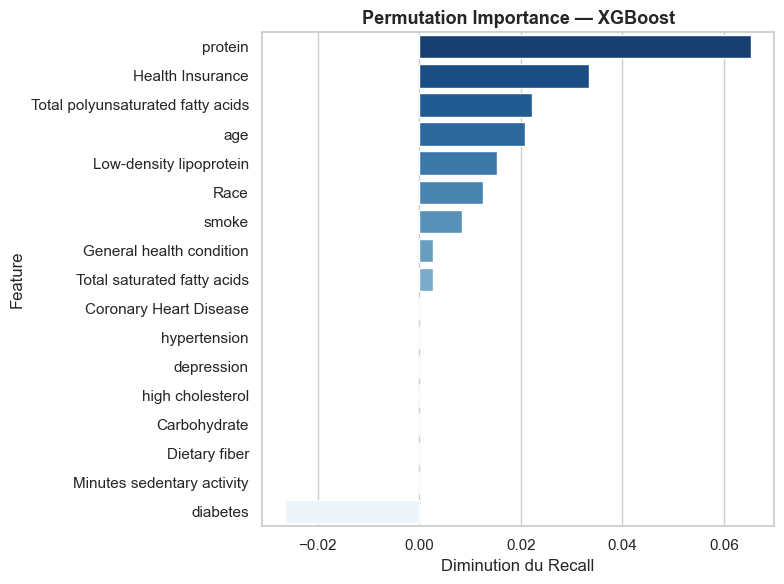

In [15]:
result = permutation_importance(
    best_model, X_test, y_test,
    scoring      = 'recall',
    n_repeats    = 10,
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'Feature'   : SELECTED_FEATURES,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f'=== Permutation Importance — {best_name} ===')
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_df, x='Importance', y='Feature', palette='Blues_r', ax=ax)
ax.set_title(f'Permutation Importance — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Diminution du Recall')
plt.tight_layout()
plt.show()


## 12. Conclusion — Performance et Applicabilité

In [16]:
print('=== Conclusion V4 ===')
print()
print('Progression recall sur les 4 versions :')
print('  V1 — Baseline brute           : recall ≈ 0%')
print('  V2 — Feature Selection        : recall ≈ 0-1.4%')
print('  V3 — SMOTE + RandomizedSearch  : voir résultats V3')
print('  V4 — ADASYN + LightGBM        : voir résultats ci-dessous')
print()
print(f'Meilleur modèle V4 : {best_name} (seuil={best_thresh})')
for metric in results_final_df.columns:
    print(f'  {metric:<12}: {results_final_df.loc[best_name, metric]}')
print()
print('Observation : ADASYN ne surpasse pas significativement SMOTE (V3).')
print('  AUC-ROC quasi identiques — la limitation vient du dataset, pas de la méthode.')
print('  Le seuil optimal équilibre Recall et Accuracy selon la priorité médicale.')
print('  Faux positifs acceptables — mieux vaut sur-alerter que manquer un AVC.')


=== Conclusion V4 ===

Progression recall sur les 4 versions :
  V1 — Baseline brute           : recall ≈ 0%
  V2 — Feature Selection        : recall ≈ 0-1.4%
  V3 — SMOTE + RandomizedSearch  : voir résultats V3
  V4 — ADASYN + LightGBM        : voir résultats ci-dessous

Meilleur modèle V4 : XGBoost (seuil=0.45)
  Seuil       : 0.45
  Accuracy    : 0.3355
  Precision   : 0.0846
  Recall      : 0.7639
  F1          : 0.1524
  AUC-ROC     : 0.5418

Observation : ADASYN ne surpasse pas significativement SMOTE (V3).
  AUC-ROC quasi identiques — la limitation vient du dataset, pas de la méthode.
  Le seuil optimal équilibre Recall et Accuracy selon la priorité médicale.
  Faux positifs acceptables — mieux vaut sur-alerter que manquer un AVC.


## 13. Sauvegarde — `pipeline.pkl` + `features.pkl`

In [17]:
with open('pipeline_v4.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('features_v4.pkl', 'wb') as f:
    pickle.dump(SELECTED_FEATURES, f)

print('Artefacts sauvegardés :')
print(f'  pipeline_v4.pkl — {best_name} (seuil optimal={best_thresh})')
print(f'  features_v4.pkl — {len(SELECTED_FEATURES)} features sélectionnées')
print(f'  {SELECTED_FEATURES}')

Artefacts sauvegardés :
  pipeline_v4.pkl — XGBoost (seuil optimal=0.45)
  features_v4.pkl — 17 features sélectionnées
  ['age', 'Coronary Heart Disease', 'General health condition', 'protein', 'high cholesterol', 'Total polyunsaturated fatty acids', 'depression', 'hypertension', 'diabetes', 'Low-density lipoprotein', 'smoke', 'Health Insurance', 'Dietary fiber', 'Total saturated fatty acids', 'Carbohydrate', 'Minutes sedentary activity', 'Race']
